<a href="https://www.kaggle.com/code/sonawanelalitsunil/smartphones-power-in-your-pocket-ml-51-50?scriptVersionId=232347017" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/smartphones/mobile_phones_2000.csv


## Title: Smartphones: Power in Your Pocket

#### Description:Discover the latest in smartphone innovation—sleek designs, powerful performance, and features that keep you connected, productive, and entertained on the go.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/smartphones/mobile_phones_2000.csv')

In [3]:
df.head()

,Brand,Model,Price (USD),Selling Platform,Rating,Refresh Rate (Hz),Screen Size (inches),RAM (GB),Storage (GB),Processor,Camera Setup
0,OnePlus,Narzo Edge 16,1286.64,Best Buy,3.5,165,7.2,16,128,Snapdragon 8+ Gen 1,12MP + 16MP + 5MP
1,Sony,Pixel Max 24,728.52,eBay,4.6,90,6.1,4,64,Dimensity 920,48MP + 8MP + 5MP
2,Samsung,Reno Plus 23,1086.68,Official Store,3.4,60,6.2,12,64,Exynos 2200,200MP + 12MP + 8MP
3,Apple,Redmi Note Mini 16,1158.78,Official Store,3.5,120,7.1,6,128,A16 Bionic,50MP + 50MP + 2MP
4,Vivo,P Series Edge 13,1656.05,Reliance Digital,4.9,165,6.1,8,512,Helio G99,64MP + 50MP + 8MP


In [4]:
df.tail()

,Brand,Model,Price (USD),Selling Platform,Rating,Refresh Rate (Hz),Screen Size (inches),RAM (GB),Storage (GB),Processor,Camera Setup
1995,Sony,Reno Max 23,210.87,eBay,4.7,144,5.3,8,128,Helio G99,48MP + 50MP + 5MP
1996,Xiaomi,iPhone Mini 21,1638.88,Best Buy,3.3,144,6.9,8,1024,Snapdragon 7 Gen 1,200MP + 12MP + 2MP
1997,Nokia,Nord Plus 24,1425.14,eBay,3.8,120,6.2,16,128,Helio G99,48MP + 16MP + 2MP
1998,OnePlus,Narzo Ultra 25,223.23,Amazon,3.6,60,7.2,12,512,Dimensity 9000,12MP + 50MP + 2MP
1999,Google,Redmi Note Turbo 22,1656.45,Walmart,4.4,60,5.7,16,1024,Tensor G1,64MP + 12MP + 2MP


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Brand                 2000 non-null   object 
 1   Model                 2000 non-null   object 
 2   Price (USD)           2000 non-null   float64
 3   Selling Platform      2000 non-null   object 
 4   Rating                2000 non-null   float64
 5   Refresh Rate (Hz)     2000 non-null   int64  
 6   Screen Size (inches)  2000 non-null   float64
 7   RAM (GB)              2000 non-null   int64  
 8   Storage (GB)          2000 non-null   int64  
 9   Processor             2000 non-null   object 
 10  Camera Setup          2000 non-null   object 
dtypes: float64(3), int64(3), object(5)
memory usage: 172.0+ KB


In [6]:
df.describe()

,Price (USD),Rating,Refresh Rate (Hz),Screen Size (inches),RAM (GB),Storage (GB)
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1085.496980,3.99005,116.086500,6.268250,9.171000,378.304000
std,526.886705,0.57630,37.199596,0.734974,4.400505,339.345696
min,151.930000,3.00000,60.000000,5.000000,4.000000,64.000000
25%,644.187500,3.50000,90.000000,5.600000,6.000000,128.000000
50%,1081.455000,4.00000,120.000000,6.300000,8.000000,256.000000
75%,1546.532500,4.50000,144.000000,6.900000,12.000000,512.000000
max,1999.260000,5.00000,165.000000,7.500000,16.000000,1024.000000


In [7]:
df.dtypes

Brand                    object
Model                    object
Price (USD)             float64
Selling Platform         object
Rating                  float64
Refresh Rate (Hz)         int64
Screen Size (inches)    float64
RAM (GB)                  int64
Storage (GB)              int64
Processor                object
Camera Setup             object
dtype: object

In [8]:
df.shape

(2000, 11)

In [9]:
df.duplicated().sum()

0

In [10]:
df.isnull().sum()

Brand                   0
Model                   0
Price (USD)             0
Selling Platform        0
Rating                  0
Refresh Rate (Hz)       0
Screen Size (inches)    0
RAM (GB)                0
Storage (GB)            0
Processor               0
Camera Setup            0
dtype: int64

In [11]:
df.columns

Index(['Brand', 'Model', 'Price (USD)', 'Selling Platform', 'Rating',
       'Refresh Rate (Hz)', 'Screen Size (inches)', 'RAM (GB)', 'Storage (GB)',
       'Processor', 'Camera Setup'],
      dtype='object')

## Data visualizations

In [12]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

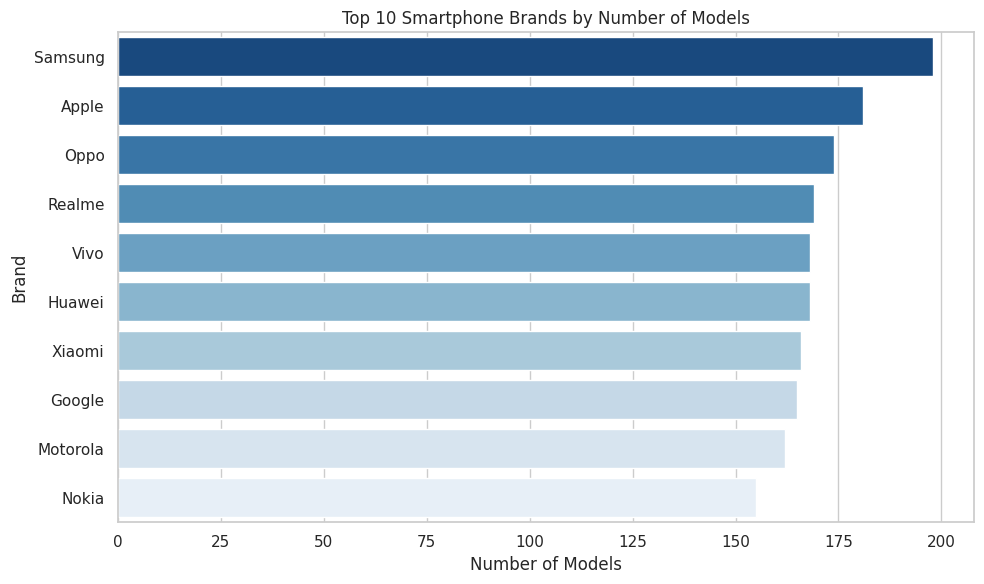

In [13]:
top_brands = df['Brand'].value_counts().head(10)

sns.barplot(x=top_brands.values, y=top_brands.index, palette='Blues_r')
plt.title('Top 10 Smartphone Brands by Number of Models')
plt.xlabel('Number of Models')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()


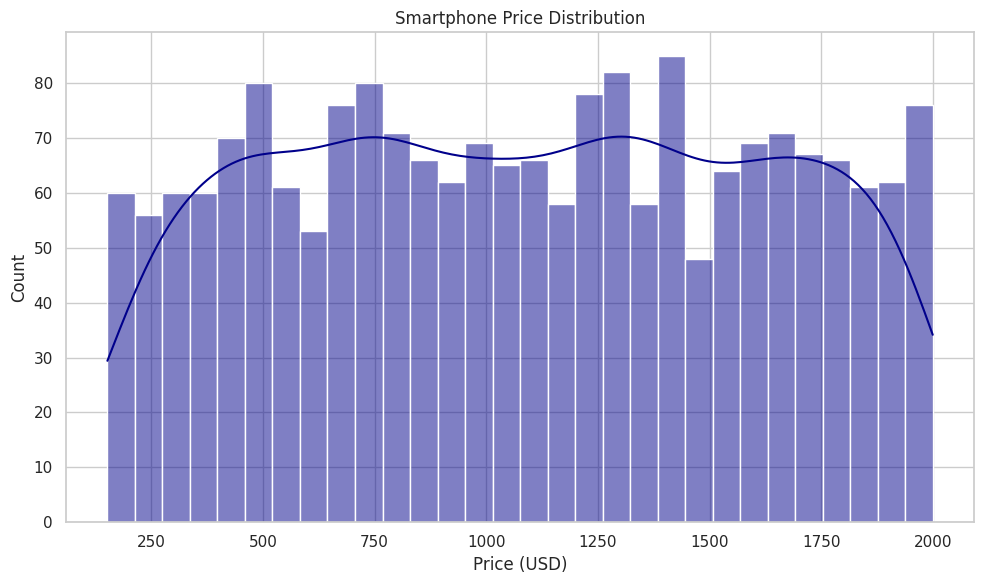

In [14]:
sns.histplot(df['Price (USD)'], bins=30, kde=True, color='darkblue')
plt.title('Smartphone Price Distribution')
plt.xlabel('Price (USD)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


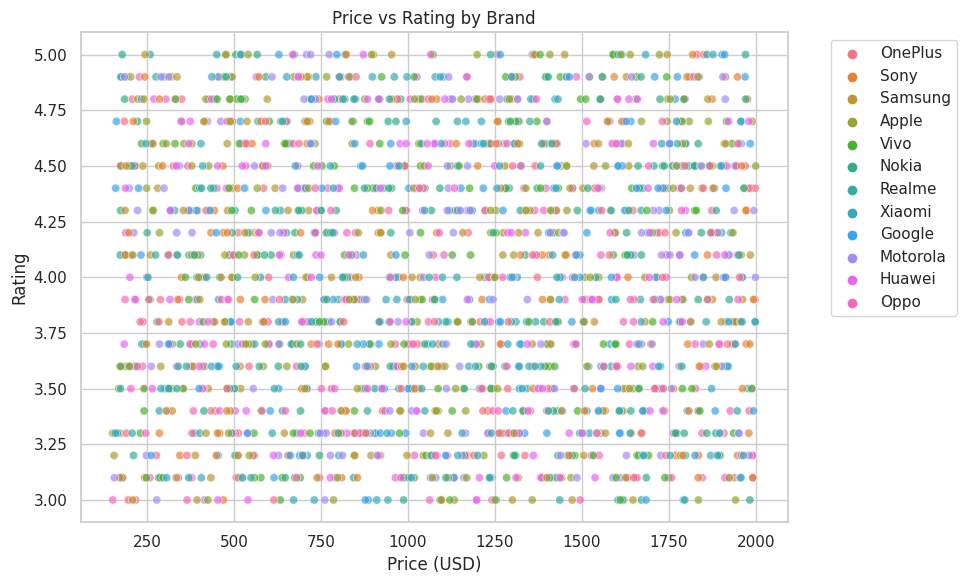

In [15]:
sns.scatterplot(data=df, x='Price (USD)', y='Rating', hue='Brand', alpha=0.7)
plt.title('Price vs Rating by Brand')
plt.xlabel('Price (USD)')
plt.ylabel('Rating')
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.tight_layout()
plt.show()


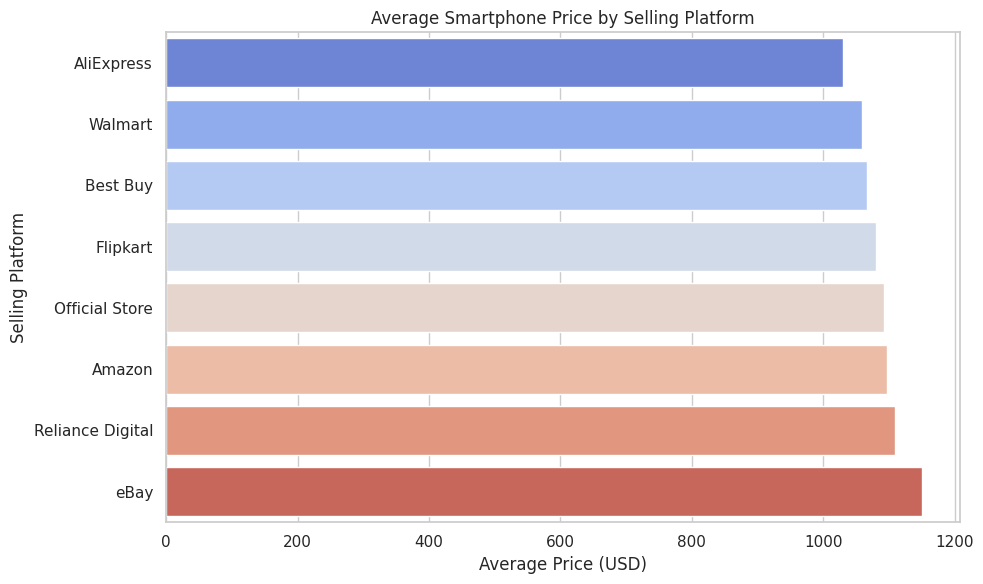

In [16]:
avg_price_platform = df.groupby('Selling Platform')['Price (USD)'].mean().sort_values()

sns.barplot(x=avg_price_platform.values, y=avg_price_platform.index, palette='coolwarm')
plt.title('Average Smartphone Price by Selling Platform')
plt.xlabel('Average Price (USD)')
plt.ylabel('Selling Platform')
plt.tight_layout()
plt.show()


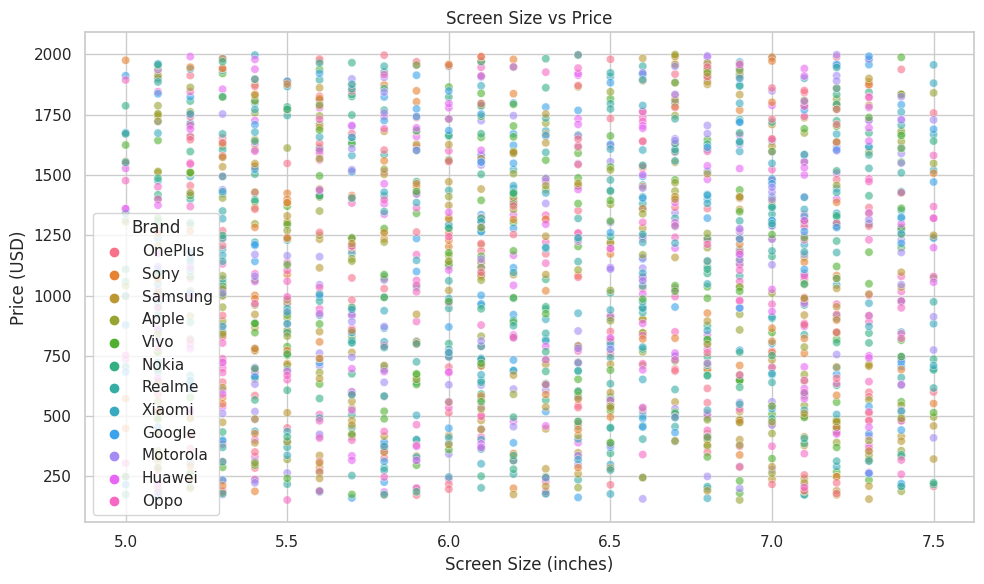

In [17]:
sns.scatterplot(data=df, x='Screen Size (inches)', y='Price (USD)', hue='Brand', alpha=0.6)
plt.title('Screen Size vs Price')
plt.xlabel('Screen Size (inches)')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()


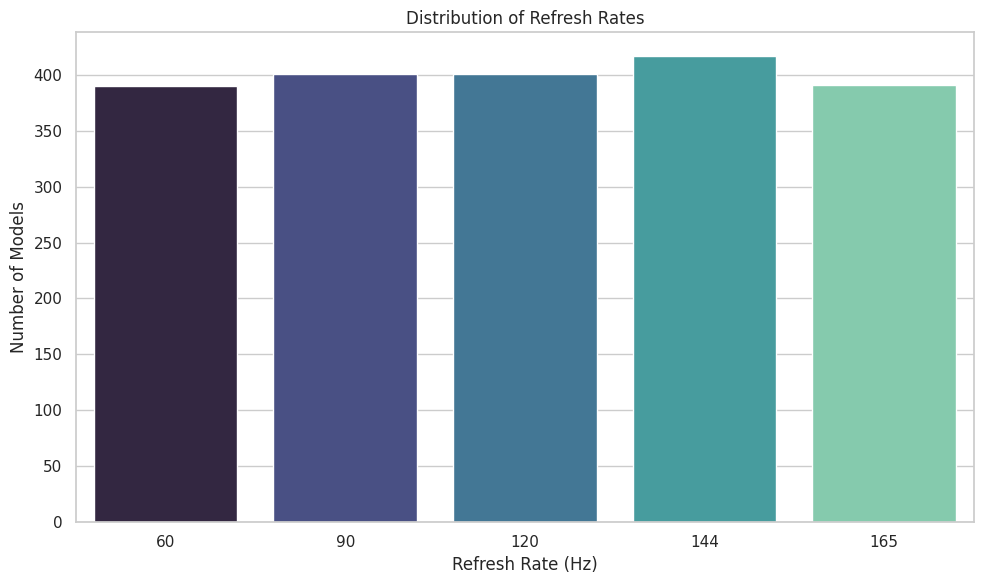

In [18]:
sns.countplot(data=df, x='Refresh Rate (Hz)', palette='mako')
plt.title('Distribution of Refresh Rates')
plt.xlabel('Refresh Rate (Hz)')
plt.ylabel('Number of Models')
plt.tight_layout()
plt.show()


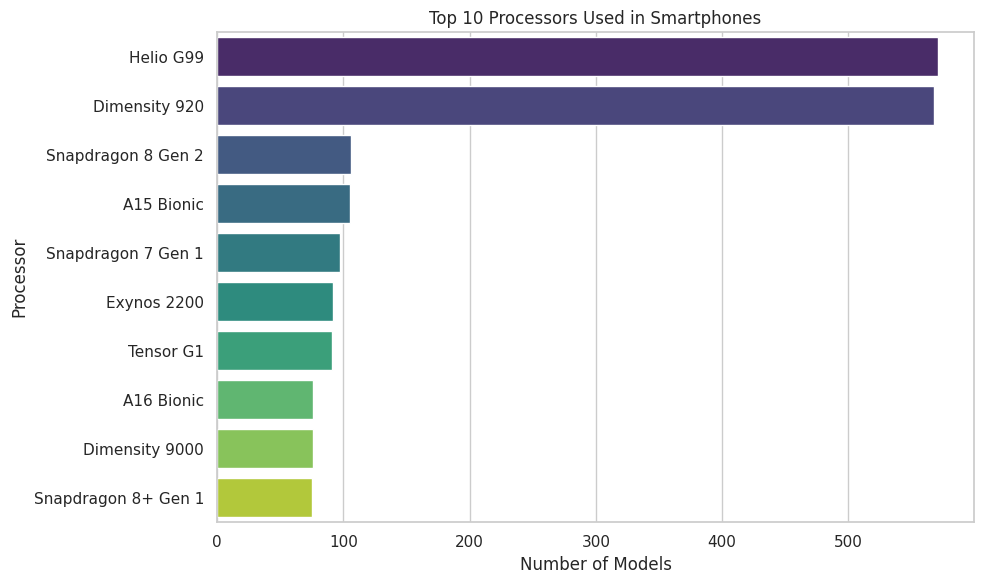

In [19]:
top_processors = df['Processor'].value_counts().head(10)

sns.barplot(x=top_processors.values, y=top_processors.index, palette='viridis')
plt.title('Top 10 Processors Used in Smartphones')
plt.xlabel('Number of Models')
plt.ylabel('Processor')
plt.tight_layout()
plt.show()


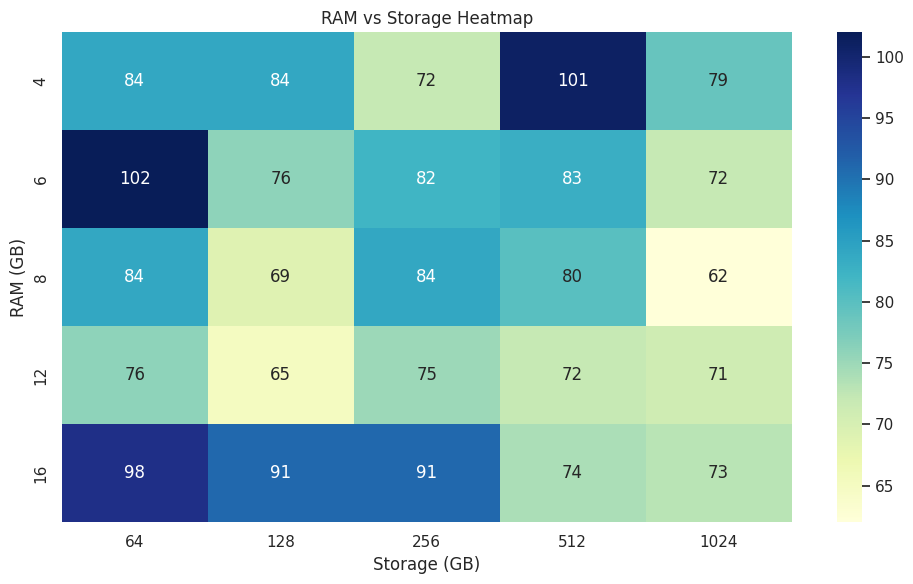

In [20]:
ram_storage = pd.crosstab(df['RAM (GB)'], df['Storage (GB)'])

sns.heatmap(ram_storage, annot=True, fmt='d', cmap='YlGnBu')
plt.title('RAM vs Storage Heatmap')
plt.xlabel('Storage (GB)')
plt.ylabel('RAM (GB)')
plt.tight_layout()
plt.show()


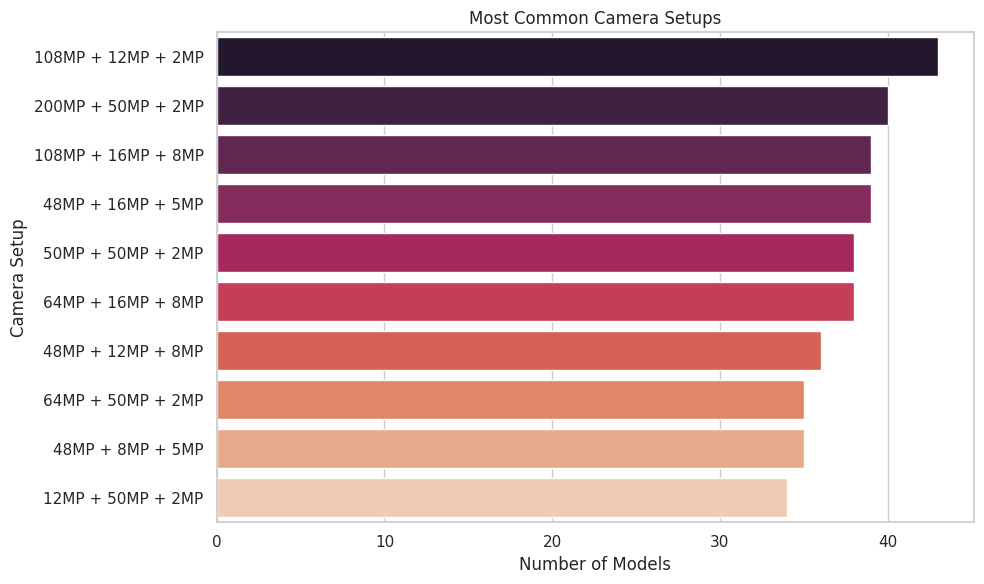

In [21]:
camera_counts = df['Camera Setup'].value_counts().head(10)

sns.barplot(x=camera_counts.values, y=camera_counts.index, palette='rocket')
plt.title('Most Common Camera Setups')
plt.xlabel('Number of Models')
plt.ylabel('Camera Setup')
plt.tight_layout()
plt.show()


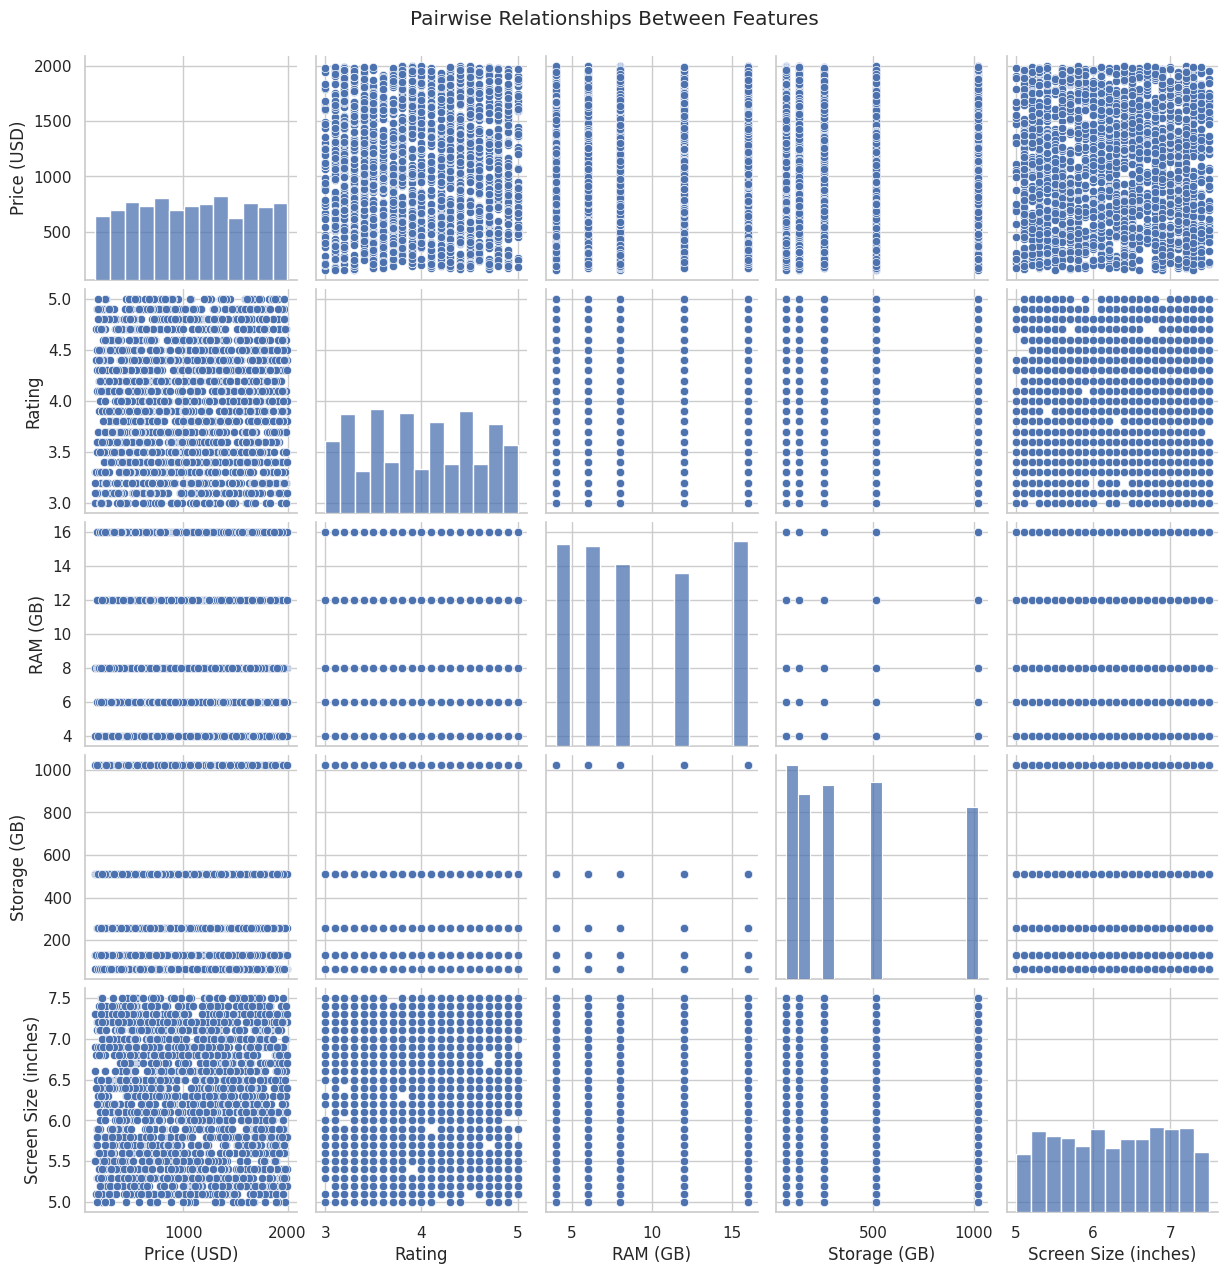

In [22]:
sns.pairplot(df[['Price (USD)', 'Rating', 'RAM (GB)', 'Storage (GB)', 'Screen Size (inches)']])
plt.suptitle('Pairwise Relationships Between Features', y=1.02)
plt.show()


## data visualizations

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [25]:
df = df.dropna()

In [26]:
target = 'Brand'
X = df.drop(columns=[target])
y = df[target]


In [27]:
# Encode categorical variables in features
X_encoded = X.copy()
label_encoders = {}

for col in X_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    label_encoders[col] = le

In [28]:
# Encode target variable
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

In [29]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

In [30]:
# Define all models to train
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

In [31]:
# Train and evaluate each model
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100  # Convert to percentage
    cm = confusion_matrix(y_test, preds)

    print(f"\n📊 {name} Accuracy: {acc:.2f}%")



📊 Logistic Regression Accuracy: 25.50%

📊 Random Forest Accuracy: 49.00%

📊 Decision Tree Accuracy: 48.75%

📊 Gradient Boosting Accuracy: 51.50%

📊 Support Vector Machine Accuracy: 8.25%

📊 K-Nearest Neighbors Accuracy: 9.50%


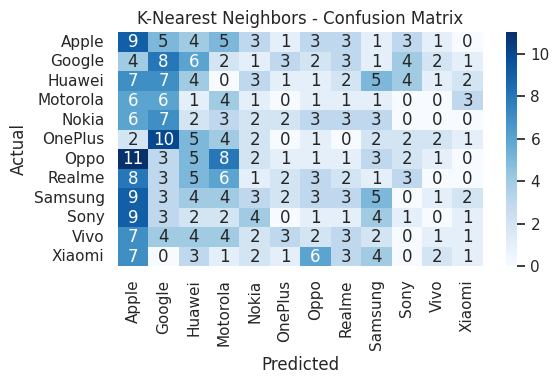

In [32]:
    # Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_encoder.classes_,
                yticklabels=target_encoder.classes_)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    results.append((name, acc))

In [33]:
# Show final summary of all accuracies
summary_df = pd.DataFrame(results, columns=['Model', 'Accuracy (%)']).sort_values(by='Accuracy (%)', ascending=False)
print("\n📈 Model Accuracy Summary:\n")
print(summary_df)


📈 Model Accuracy Summary:

                 Model  Accuracy (%)
0  K-Nearest Neighbors           9.5
